# RNAD Loss Function Visualization

This notebook visualizes the current RNAD loss defined in `losses/rnad.py`.

The implementation combines three pieces:

1. **Regime-normalized magnitude loss** with a smooth L2/Charbonnier transition
2. **Noise-aware directional loss** using `tanh`-encoded returns
3. **Volatility normalization** from a batch statistic blended with an EMA memory

For the real forward pass, RNAD computes

$$
\sigma = \sqrt{\text{batch\_vol} \cdot \text{ema\_vol} + \epsilon},
\qquad \text{batch\_vol} = \sqrt{\mathbb{E}[\Delta_{true}^2] + \epsilon}
$$

with

$$
u = \frac{y_{pred} - y_{true}}{\sigma}, \qquad
v_{true} = \frac{y_{true} - y_{prev}}{\sigma}, \qquad
v_{pred} = \frac{y_{pred} - y_{prev}}{\sigma}
$$

and losses

$$
L_{mag} = (1-g_{tail})\,\frac{1}{2}u^2 + g_{tail}\left(\sqrt{u^2 + \epsilon_c^2} - \epsilon_c\right)
$$

$$
g_{tail} = \operatorname{sigmoid}\left(\frac{|u| - \tau}{T_{tail} + \epsilon}\right)
$$

$$
L_{dir} = g_{noise}\,\text{softplus}\left(-\kappa\,\tanh(\beta v_{true})\tanh(\beta v_{pred})\right)
$$

$$
g_{noise} = \operatorname{sigmoid}\left(\frac{|v_{true}| - n}{T_{noise} + \epsilon}\right),
\qquad L = L_{mag} + \lambda_{dir} L_{dir}
$$

Because the batch EMA makes the true forward pass stateful, the visualization freezes the volatility scale at $\sigma = 1.0$ and evaluates each grid point independently.

The plotted surface uses:

- **X-axis**: error $e = y_{pred} - y_{true}$
- **Y-axis**: true return $\Delta_{true} = y_{true} - y_{prev}$

This gives a deterministic view of the current RNAD geometry without EMA drift.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

# Add the workspace root to the import path so `losses.rnad` can be imported
# whether the notebook is executed from the repo root or from `notebooks/`.
workspace_root = Path.cwd()
if not (workspace_root / "losses").exists() and (workspace_root.parent / "losses").exists():
    workspace_root = workspace_root.parent
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from losses.rnad import RNAD


class FixedSigmaRNAD(RNAD):
    """RNAD wrapper with a frozen volatility scale for deterministic plots."""

    def __init__(self, sigma: float = 1.0, **kwargs):
        kwargs.setdefault("vol_momentum", 0.0)
        super().__init__(**kwargs)
        self.fixed_sigma = float(sigma)

    def _compute_scale(self, delta_true: torch.Tensor) -> torch.Tensor:
        return torch.full_like(delta_true, self.fixed_sigma)


visual_rnad = FixedSigmaRNAD(
    sigma=1.0,
    lambda_dir=0.5,
    tail_tau=1.1,
    tail_temp=0.30,
    charb_eps=1e-3,
    beta=4.5,
    kappa=4.5,
    noise_level=0.10,
    noise_temp=0.04,
)
visual_rnad.eval()


def rnad_surface_from_error_delta(
    error_grid,
    delta_true_grid,
    *,
    y_prev: float = 0.0,
    model: FixedSigmaRNAD = visual_rnad,
):
    """Evaluate RNAD terms pointwise for a grid of (error, true return) values."""

    with torch.no_grad():
        error = torch.as_tensor(error_grid, dtype=torch.float32)
        delta_true = torch.as_tensor(delta_true_grid, dtype=torch.float32)
        y_prev_t = torch.as_tensor(y_prev, dtype=torch.float32, device=error.device)

        def scalar(value: float) -> torch.Tensor:
            return torch.as_tensor(value, dtype=error.dtype, device=error.device)

        y_true = y_prev_t + delta_true
        y_pred = y_true + error

        sigma = scalar(model.fixed_sigma)
        eps = scalar(model.eps)

        # Exact RNAD variables for a frozen-volatility visualization.
        u = error / sigma
        v_true = delta_true / sigma
        v_pred = (y_pred - y_prev_t) / sigma

        tail_tau = scalar(model.tail_tau)
        tail_temp = scalar(model.tail_temp)
        charb_eps = scalar(model.charb_eps)
        noise_level = scalar(model.noise_level)
        noise_temp = scalar(model.noise_temp)
        beta = scalar(model.beta)
        kappa = scalar(model.kappa)
        lambda_dir = scalar(model.lambda_dir)

        tail_gate = torch.sigmoid((u.abs() - tail_tau) / (tail_temp + eps))
        l2 = 0.5 * u.pow(2)
        charb = torch.sqrt(u.pow(2) + charb_eps.pow(2)) - charb_eps
        magnitude = (1.0 - tail_gate) * l2 + tail_gate * charb

        noise_gate = torch.sigmoid((v_true.abs() - noise_level) / (noise_temp + eps))
        t = torch.tanh(beta * v_true)
        p = torch.tanh(beta * v_pred)
        direction = noise_gate * F.softplus(-kappa * t * p)

        total = magnitude + lambda_dir * direction

        return (
            total.cpu().numpy(),
            magnitude.cpu().numpy(),
            direction.cpu().numpy(),
        )

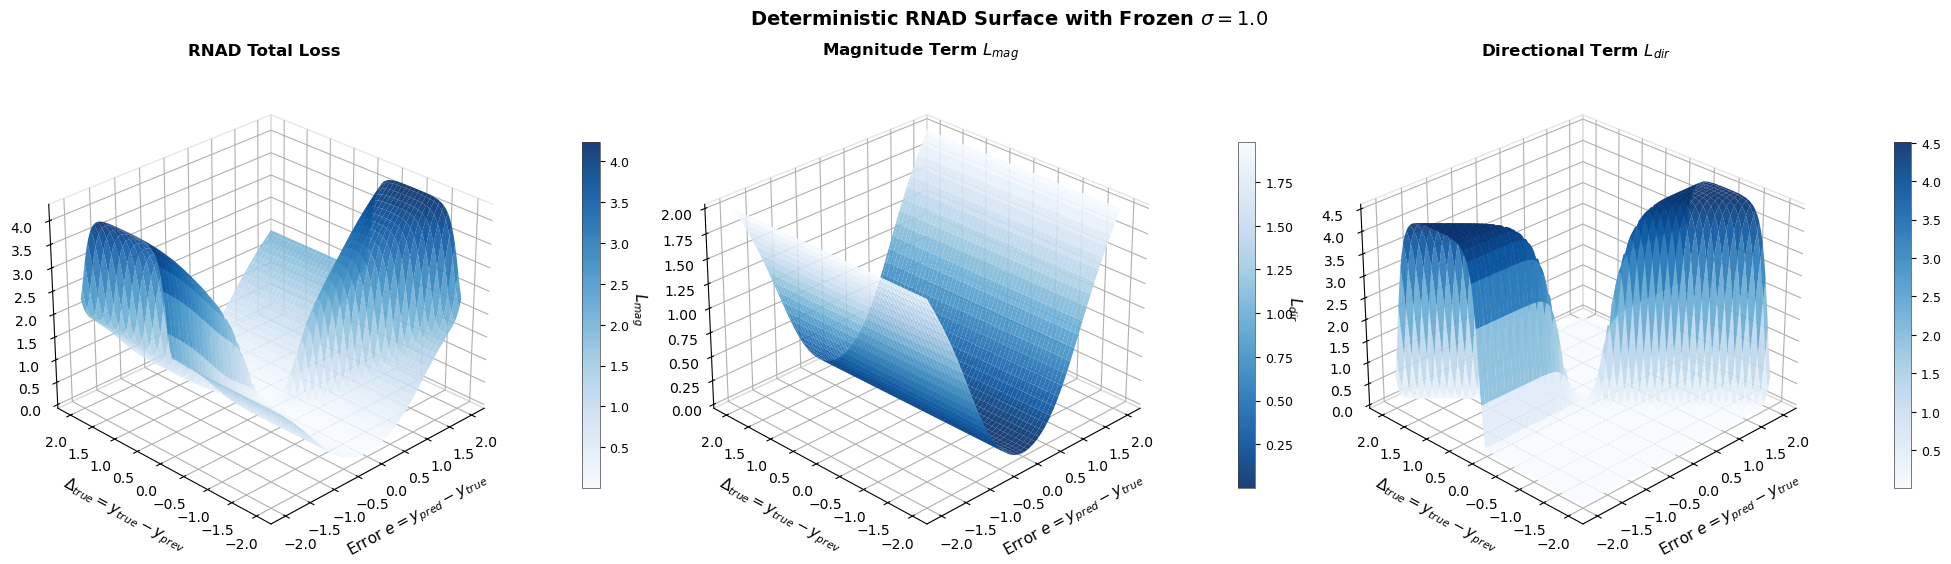

In [2]:
# Grid over the correct RNAD coordinates: error and true return.
error_range = np.linspace(-2.0, 2.0, 100)
delta_true_range = np.linspace(-2.0, 2.0, 100)
ERROR, DELTA_TRUE = np.meshgrid(error_range, delta_true_range)

y_prev = 0.0
TOTAL, MAGNITUDE, DIRECTION = rnad_surface_from_error_delta(
    ERROR,
    DELTA_TRUE,
    y_prev=y_prev,
    model=visual_rnad,
)

# Professional styling with blue-centric color palette
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'sans-serif',
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Create figure with professional styling
fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6),
    subplot_kw={"projection": "3d"},
    facecolor='white',
    edgecolor='none',
)

# Blue-centric color palette: Blues, Blues with depth, and blue-gray gradient
surface_specs = [
    (TOTAL, "RNAD Total Loss", "Blues", "Total Loss"),
    (MAGNITUDE, r"Magnitude Term $L_{mag}$", "Blues_r", r"$L_{mag}$"),
    (DIRECTION, r"Directional Term $L_{dir}$", "Blues", r"$L_{dir}$"),
]

for ax, (surface, title, cmap, zlabel) in zip(axes, surface_specs):
    surf = ax.plot_surface(
        ERROR,
        DELTA_TRUE,
        surface,
        cmap=cmap,
        edgecolor="none",
        linewidth=0,
        antialiased=True,
        alpha=0.92,
        shade=True,
    )
    ax.set_xlabel(r"Error $e = y_{pred} - y_{true}$", fontsize=11, labelpad=8)
    ax.set_ylabel(r"$\Delta_{true} = y_{true} - y_{prev}$", fontsize=11, labelpad=8)
    ax.set_zlabel(zlabel, fontsize=11, labelpad=8)
    ax.set_title(title, fontsize=12, fontweight='semibold', pad=15)
    ax.view_init(elev=28, azim=-135)
    
    # Professional colorbar styling
    cbar = fig.colorbar(surf, ax=ax, shrink=0.65, pad=0.12)
    cbar.outline.set_linewidth(0.5)
    cbar.outline.set_edgecolor('#404040')
    cbar.ax.tick_params(labelsize=9)
    
    # Improve axis styling
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('#d0d0d0')
    ax.yaxis.pane.set_edgecolor('#d0d0d0')
    ax.zaxis.pane.set_edgecolor('#d0d0d0')

fig.suptitle(r"Deterministic RNAD Surface with Frozen $\sigma = 1.0$", 
             fontsize=14, fontweight='semibold', y=0.98)
fig.tight_layout()
fig.savefig("rnad_surface.pdf", bbox_inches="tight", dpi=300, facecolor='white', edgecolor='none')
plt.show()
